Main notebook for coding and testing.

In [116]:
#%pip install --upgrade pip

# %pip install pandas 
# %pip install numpy 
# %pip install matplotlib 
# %pip install seaborn
# %pip install xlrd
# %pip install scipy
#%pip install statsmodels
#%pip install pandas-datareader
%pip install fredapi

Note: you may need to restart the kernel to use updated packages.


In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm #(change to the version from jacob (gmail))
from fredapi import Fred
import datetime

Read in data and do basic cleaning

In [118]:
# sentiment_data = pd.read_excel('data/sentiment_data.xls', header=3)

In [119]:
# cleaned_sentiment_data = sentiment_data[sentiment_data.index <= 2020]

# cleaned_sentiment_data['Date'] = pd.to_datetime(cleaned_sentiment_data['Date'])

# cleaned_sentiment_data = cleaned_sentiment_data[cleaned_sentiment_data['Date'].notna()].drop(columns=['Unnamed: 13'])

# cleaned_sentiment_data = cleaned_sentiment_data.rename(columns={'High':'S&P High', 'Low':'S&P Low', 'Close':'S&P Close'})

# display(cleaned_sentiment_data)

# pd.to_pickle(cleaned_sentiment_data, 'cleaned_sentiment_data.pkl')



Read in cleaned data

In [120]:
s_df = pd.read_pickle('cleaned_sentiment_data.pkl')
s_df['Date'] = pd.to_datetime(s_df['Date'])

display(s_df)

,Date,Bullish,Neutral,Bearish,Total,Mov Avg,Spread,Average,+St. Dev.,- St. Dev.,S&P High,S&P Low,S&P Close
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,0.376221,0.476428,0.276013,NaN,NaN,NaN
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,NaN,0.376221,0.476428,0.276013,314.59,307.63,314.59
3,1987-07-24,0.360000,0.50000,0.140000,1.000000,NaN,0.220000,0.376221,0.476428,0.276013,311.39,307.81,309.27
4,1987-07-31,0.260000,0.48000,0.260000,1.000000,NaN,0.000000,0.376221,0.476428,0.276013,318.66,310.65,318.66
5,1987-08-07,0.560000,0.15000,0.290000,1.000000,NaN,0.270000,0.376221,0.476428,0.276013,323.00,316.23,323.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,1.000001,0.395061,-0.024793,0.376221,0.476428,0.276013,6947.25,6710.42,6869.50
2017,2026-03-12,0.319392,0.21673,0.463878,1.000000,0.373107,-0.144486,0.376221,0.476428,0.276013,6870.43,6636.04,6775.80
2018,2026-03-19,0.304000,0.17600,0.520000,1.000000,0.357151,-0.216000,0.376221,0.476428,0.276013,6754.30,6621.66,6624.70
2019,2026-03-26,0.320988,0.18107,0.497942,1.000000,0.341774,-0.176954,0.376221,0.476428,0.276013,6651.62,6473.52,6591.90


In [121]:
display(s_df.info())

display(s_df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 2020 entries, 1 to 2020
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2020 non-null   datetime64[us]
 1   Bullish     2017 non-null   float64       
 2   Neutral     2017 non-null   float64       
 3   Bearish     2017 non-null   float64       
 4   Total       2017 non-null   float64       
 5   Mov Avg     2003 non-null   float64       
 6   Spread      2017 non-null   float64       
 7   Average     2020 non-null   float64       
 8   +St. Dev.   2020 non-null   float64       
 9   - St. Dev.  2020 non-null   float64       
 10  S&P High    2019 non-null   float64       
 11  S&P Low     2019 non-null   float64       
 12  S&P Close   2019 non-null   float64       
dtypes: datetime64[us](1), float64(12)
memory usage: 205.3 KB


None

,Date,Bullish,Neutral,Bearish,Total,Mov Avg,Spread,Average,+St. Dev.,- St. Dev.,S&P High,S&P Low,S&P Close
count,2020,2017.000000,2017.000000,2017.000000,2017.000000,2003.000000,2017.000000,2020.000000,2020.000000,2020.000000,2019.000000,2019.000000,2019.000000
mean,2006-11-18 05:40:02.376237,0.376221,0.310635,0.313143,0.999999,0.375845,0.063077,0.376220,0.476429,0.276011,1776.076360,1729.207499,1756.605254
min,1987-06-26 00:00:00,0.120000,0.076900,0.060000,0.999600,0.175000,-0.540000,0.375021,0.476428,0.273423,233.450000,223.920000,223.920000
25%,1997-03-11 06:00:00,0.303000,0.252000,0.240625,1.000000,0.319334,-0.058900,0.376221,0.476428,0.276013,790.305000,764.530000,775.025000
50%,2006-11-19 12:00:00,0.372500,0.310000,0.300000,1.000000,0.375628,0.070000,0.376221,0.476428,0.276013,1277.630000,1253.120000,1267.430000
75%,2016-07-22 18:00:00,0.440000,0.365759,0.373984,1.000000,0.428887,0.187310,0.376221,0.476428,0.276013,2151.989990,2099.885000,2132.514966
max,2026-04-02 00:00:00,0.750000,0.620000,0.702700,1.002000,0.644650,0.628600,0.376221,0.476882,0.276013,7002.280000,6899.330000,6978.030000
std,NaN,0.100208,0.081395,0.098547,0.000056,0.078673,0.181330,0.000033,0.000011,0.000075,1515.280246,1476.109334,1500.016716


From the raw means we can see that Bullish has a mean of 37.%, Neutral has 31.06% and Bearish has 31.31%. This suggests that investors predicted bull more often. 

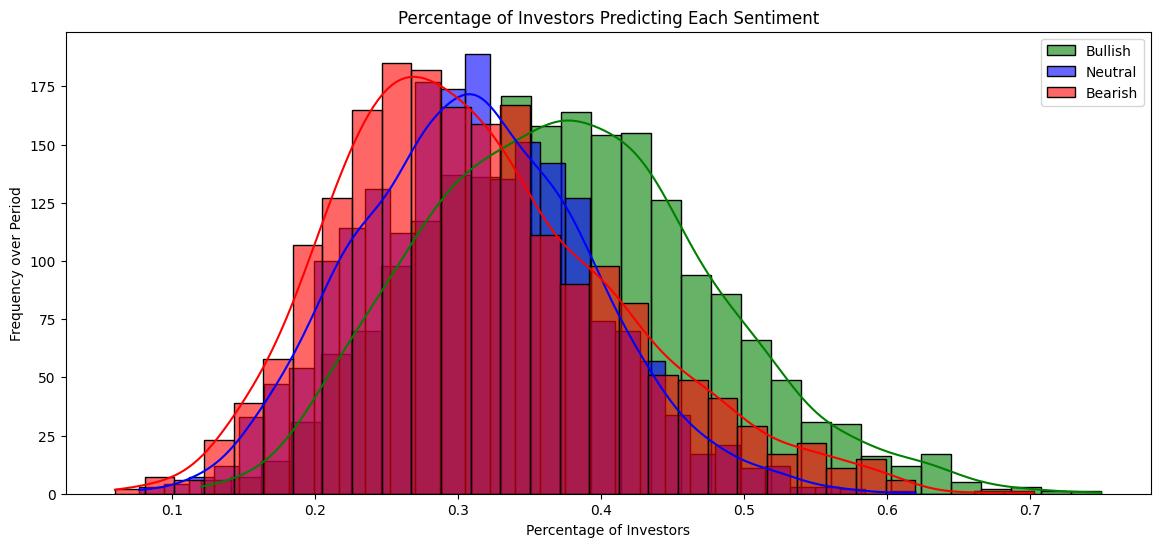

In [122]:
plt.figure(figsize=(14,6))

sns.histplot(s_df['Bullish'], kde=True, color='green', label='Bullish', alpha=0.6)
sns.histplot(s_df['Neutral'], kde=True, color='blue', label='Neutral', alpha=0.6)
sns.histplot(s_df['Bearish'], kde=True, color='red', label='Bearish', alpha=0.6)


plt.title('Percentage of Investors Predicting Each Sentiment')
plt.xlabel('Percentage of Investors')
plt.ylabel('Frequency over Period')
plt.legend()
plt.show()

In [123]:
s_df['Weekly Return'] = s_df['S&P Close'].pct_change()


display(s_df)

display(s_df.describe())




,Date,Bullish,Neutral,Bearish,Total,Mov Avg,Spread,Average,+St. Dev.,- St. Dev.,S&P High,S&P Low,S&P Close,Weekly Return
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,0.376221,0.476428,0.276013,NaN,NaN,NaN,NaN
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,NaN,0.376221,0.476428,0.276013,314.59,307.63,314.59,NaN
3,1987-07-24,0.360000,0.50000,0.140000,1.000000,NaN,0.220000,0.376221,0.476428,0.276013,311.39,307.81,309.27,-0.016911
4,1987-07-31,0.260000,0.48000,0.260000,1.000000,NaN,0.000000,0.376221,0.476428,0.276013,318.66,310.65,318.66,0.030362
5,1987-08-07,0.560000,0.15000,0.290000,1.000000,NaN,0.270000,0.376221,0.476428,0.276013,323.00,316.23,323.00,0.013620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,1.000001,0.395061,-0.024793,0.376221,0.476428,0.276013,6947.25,6710.42,6869.50,-0.011032
2017,2026-03-12,0.319392,0.21673,0.463878,1.000000,0.373107,-0.144486,0.376221,0.476428,0.276013,6870.43,6636.04,6775.80,-0.013640
2018,2026-03-19,0.304000,0.17600,0.520000,1.000000,0.357151,-0.216000,0.376221,0.476428,0.276013,6754.30,6621.66,6624.70,-0.022300
2019,2026-03-26,0.320988,0.18107,0.497942,1.000000,0.341774,-0.176954,0.376221,0.476428,0.276013,6651.62,6473.52,6591.90,-0.004951


,Date,Bullish,Neutral,Bearish,Total,Mov Avg,Spread,Average,+St. Dev.,- St. Dev.,S&P High,S&P Low,S&P Close,Weekly Return
count,2020,2017.000000,2017.000000,2017.000000,2017.000000,2003.000000,2017.000000,2020.000000,2020.000000,2020.000000,2019.000000,2019.000000,2019.000000,2018.000000
mean,2006-11-18 05:40:02.376237,0.376221,0.310635,0.313143,0.999999,0.375845,0.063077,0.376220,0.476429,0.276011,1776.076360,1729.207499,1756.605254,0.001766
min,1987-06-26 00:00:00,0.120000,0.076900,0.060000,0.999600,0.175000,-0.540000,0.375021,0.476428,0.273423,233.450000,223.920000,223.920000,-0.151689
25%,1997-03-11 06:00:00,0.303000,0.252000,0.240625,1.000000,0.319334,-0.058900,0.376221,0.476428,0.276013,790.305000,764.530000,775.025000,-0.009016
50%,2006-11-19 12:00:00,0.372500,0.310000,0.300000,1.000000,0.375628,0.070000,0.376221,0.476428,0.276013,1277.630000,1253.120000,1267.430000,0.003456
75%,2016-07-22 18:00:00,0.440000,0.365759,0.373984,1.000000,0.428887,0.187310,0.376221,0.476428,0.276013,2151.989990,2099.885000,2132.514966,0.014092
max,2026-04-02 00:00:00,0.750000,0.620000,0.702700,1.002000,0.644650,0.628600,0.376221,0.476882,0.276013,7002.280000,6899.330000,6978.030000,0.113127
std,NaN,0.100208,0.081395,0.098547,0.000056,0.078673,0.181330,0.000033,0.000011,0.000075,1515.280246,1476.109334,1500.016716,0.022640


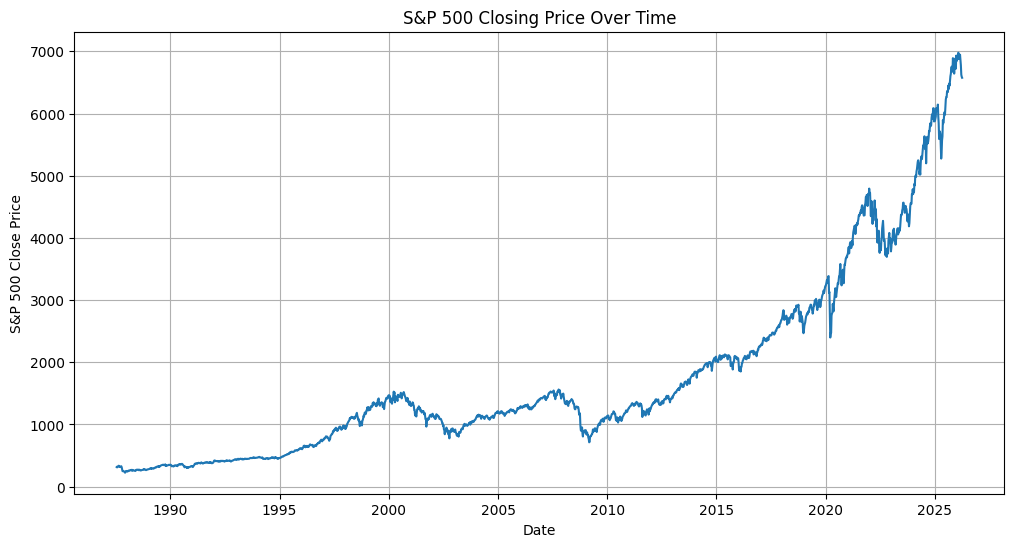

In [124]:
plt.figure(figsize=(12,6))
sns.lineplot(data=s_df, x='Date', y='S&P Close')
plt.title('S&P 500 Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('S&P 500 Close Price')
plt.grid()



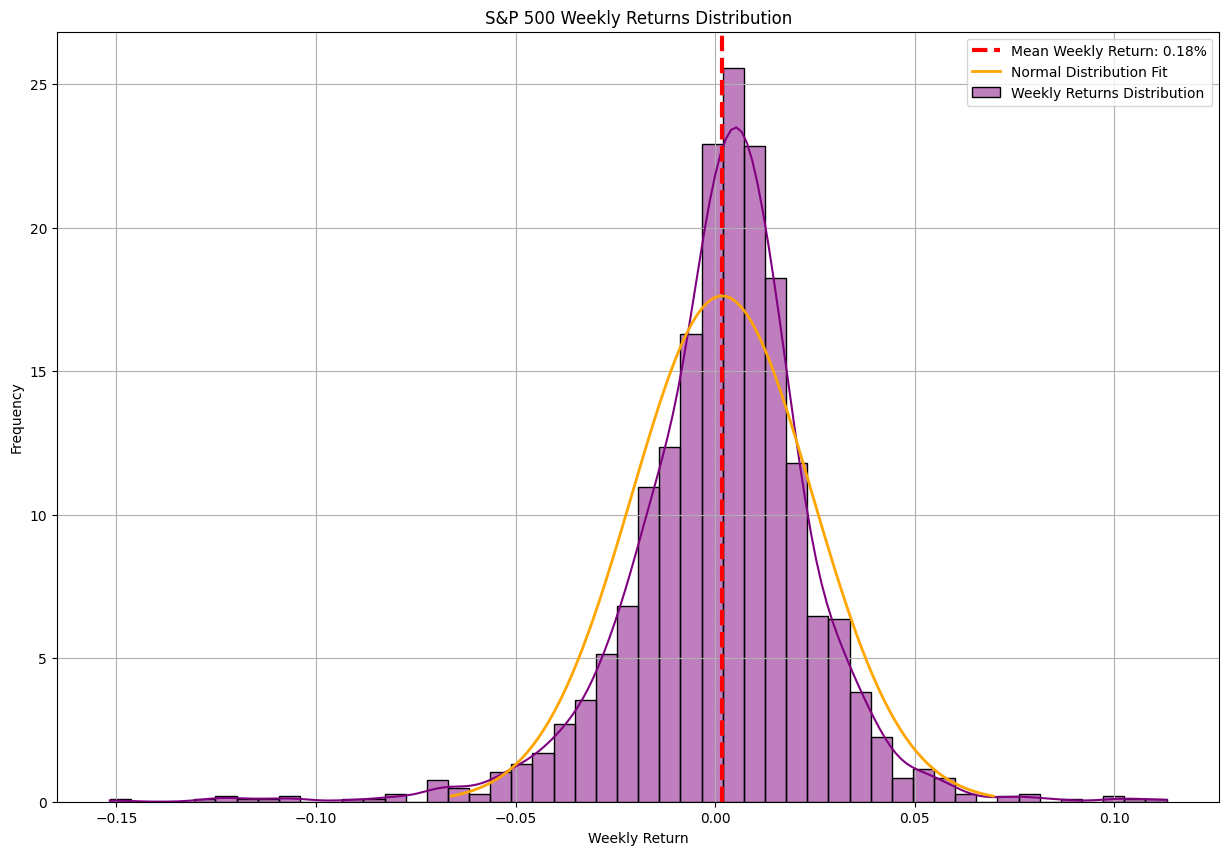

In [125]:
plt.figure(figsize=(15,10))
sns.histplot(data=s_df, x='Weekly Return', bins=50, kde=True, stat='density', color='purple', label='Weekly Returns Distribution')
plt.axvline(s_df['Weekly Return'].mean(), color='red', linestyle='dashed', linewidth=3, label=f'Mean Weekly Return: {s_df["Weekly Return"].mean()*100:.2f}%')

plt.title('S&P 500 Weekly Returns Distribution')
plt.xlabel('Weekly Return')
plt.ylabel('Frequency')

# Source - https://stackoverflow.com/a/10138308
# Posted by unutbu, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-19, License - CC BY-SA 4.0

mu = s_df['Weekly Return'].mean()
variance = s_df['Weekly Return'].var()
sigma = np.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)

sns.lineplot(x=x, y=stats.norm.pdf(x, mu, sigma), color='orange', linewidth=2, label='Normal Distribution Fit')

plt.legend()

plt.grid()
plt.show()

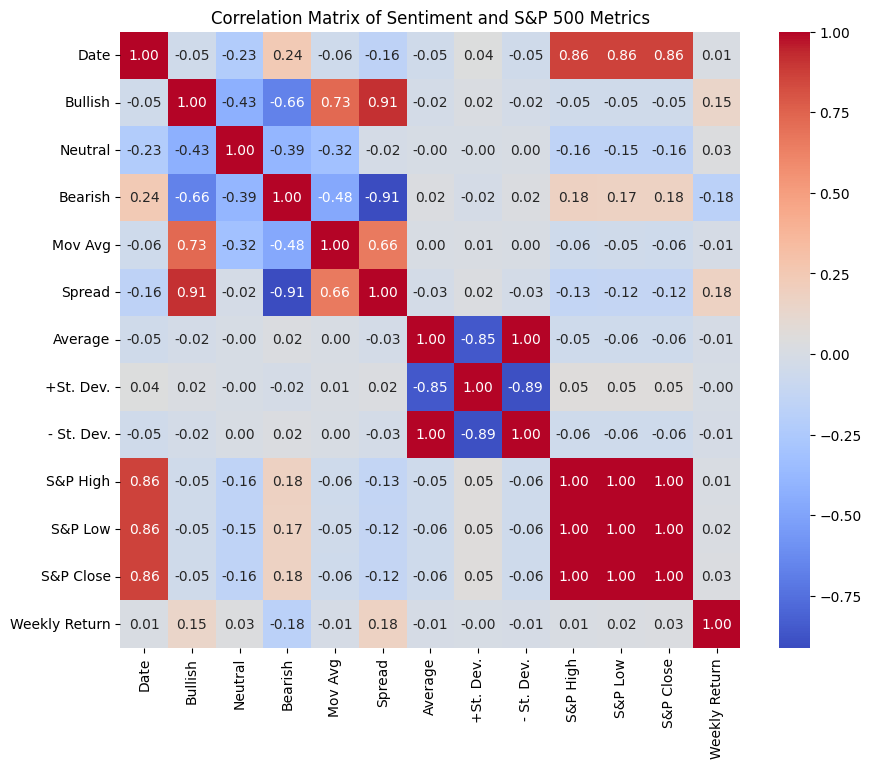

In [126]:
correlation_matrix = s_df.drop(columns=['Total']).corr(method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Sentiment and S&P 500 Metrics')
plt.show()



In [127]:
threshold = 0

# +1 = long, -1 = short, 0 = no position
raw_signal = np.select(
    [s_df['Spread'] > threshold, s_df['Spread'] < -threshold],
    [1, -1],
    default=0
 )

# Shift by 1 week to avoid look-ahead bias
s_df['Signal'] = pd.Series(raw_signal, index=s_df.index).shift(1).fillna(0).astype(int)

# Weekly equity return (decimal form)
s_df['Weekly Return'] = s_df['S&P Close'].pct_change().fillna(0)

s_df['Weekly Return Direction'] = np.sign(s_df['Weekly Return']).fillna(0).astype(int)

In [128]:
s_df['Accuracy'] = np.where(s_df['Signal'] == s_df['Weekly Return Direction'], 1, 0)

#s_df.drop(s_df['Date'] == 1987-01-01, inplace=True)

In [129]:
display(s_df[['Date', 'Bullish', 'Bearish', 'Spread', 'Signal', 'Weekly Return', 'Weekly Return Direction', 'Accuracy']].head())

,Date,Bullish,Bearish,Spread,Signal,Weekly Return,Weekly Return Direction,Accuracy
1,1987-06-26,NaN,NaN,NaN,0,0.000000,0,1
2,1987-07-17,NaN,NaN,NaN,0,0.000000,0,1
3,1987-07-24,0.36,0.14,0.22,0,-0.016911,-1,0
4,1987-07-31,0.26,0.26,0.00,1,0.030362,1,1
5,1987-08-07,0.56,0.29,0.27,0,0.013620,1,0


In [130]:
s_df['Signal'].value_counts()

Signal
 1    1277
-1     691
 0      52
Name: count, dtype: int64

In [131]:
fred = Fred(api_key='2156df4aac1a73d06c92ece4a988135f')
start = datetime.datetime(s_df['Date'].iloc[0].year, 1, 1)
end = datetime.datetime.today()

rf_data = (fred.get_series('WTB3MS', start, end)/100)/52

rf_data = rf_data.reindex(s_df['Date'], method='ffill')

display((rf_data))

Date
1987-06-26    0.001110
1987-07-17    0.001073
1987-07-24    0.001088
1987-07-31    0.001142
1987-08-07    0.001129
                ...   
2026-03-05    0.000692
2026-03-12    0.000692
2026-03-19    0.000694
2026-03-26    0.000696
2026-04-02    0.000698
Length: 2020, dtype: float64

In [132]:
s_df['Risk-Free Rate'] = rf_data.to_numpy()


display(s_df)


,Date,Bullish,Neutral,Bearish,Total,Mov Avg,Spread,Average,+St. Dev.,- St. Dev.,S&P High,S&P Low,S&P Close,Weekly Return,Signal,Weekly Return Direction,Accuracy,Risk-Free Rate
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,0.376221,0.476428,0.276013,NaN,NaN,NaN,0.000000,0,0,1,0.001110
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,NaN,0.376221,0.476428,0.276013,314.59,307.63,314.59,0.000000,0,0,1,0.001073
3,1987-07-24,0.360000,0.50000,0.140000,1.000000,NaN,0.220000,0.376221,0.476428,0.276013,311.39,307.81,309.27,-0.016911,0,-1,0,0.001088
4,1987-07-31,0.260000,0.48000,0.260000,1.000000,NaN,0.000000,0.376221,0.476428,0.276013,318.66,310.65,318.66,0.030362,1,1,1,0.001142
5,1987-08-07,0.560000,0.15000,0.290000,1.000000,NaN,0.270000,0.376221,0.476428,0.276013,323.00,316.23,323.00,0.013620,0,1,0,0.001129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,1.000001,0.395061,-0.024793,0.376221,0.476428,0.276013,6947.25,6710.42,6869.50,-0.011032,-1,-1,1,0.000692
2017,2026-03-12,0.319392,0.21673,0.463878,1.000000,0.373107,-0.144486,0.376221,0.476428,0.276013,6870.43,6636.04,6775.80,-0.013640,-1,-1,1,0.000692
2018,2026-03-19,0.304000,0.17600,0.520000,1.000000,0.357151,-0.216000,0.376221,0.476428,0.276013,6754.30,6621.66,6624.70,-0.022300,-1,-1,1,0.000694
2019,2026-03-26,0.320988,0.18107,0.497942,1.000000,0.341774,-0.176954,0.376221,0.476428,0.276013,6651.62,6473.52,6591.90,-0.004951,-1,-1,1,0.000696


In [133]:
s_df['Excess Market Returns'] = s_df['Weekly Return'] - s_df['Risk-Free Rate']


In [134]:


# Strategy returns on a common timeline (all weeks)
s_df['Strategy Return'] = s_df['Signal'] * s_df['Excess Market Returns']
s_df['Long Leg Return'] = np.where(s_df['Signal'] == 1, s_df['Excess Market Returns'], 0.0)
s_df['Short Leg Return'] = np.where(s_df['Signal'] == -1, -s_df['Excess Market Returns'], 0.0)

portfolio_return = (1 + s_df['Strategy Return']).prod() - 1
buy_hold_return = (1 + s_df['Excess Market Returns']).prod() - 1
long_leg_return = (1 + s_df['Long Leg Return']).prod() - 1
short_leg_return = (1 + s_df['Short Leg Return']).prod() - 1

# Accuracy metric: did sentiment sign correctly predict next week's return sign?

directional_accuracy = s_df[s_df['Signal'] != 0]['Accuracy'].mean()

display({'portfolio_return': portfolio_return})
display({'buy_hold_return': buy_hold_return})
display({'long_leg_return': long_leg_return})
display({'short_leg_return': short_leg_return})
display({'directional_accuracy_active_weeks': directional_accuracy})
display(s_df['Signal'].value_counts())

{'portfolio_return': np.float64(-0.7527739134559237)}

{'buy_hold_return': np.float64(5.519030197199724)}

{'long_leg_return': np.float64(0.808798065195498)}

{'short_leg_return': np.float64(-0.8633202393892674)}

{'directional_accuracy_active_weeks': np.float64(0.5233739837398373)}

Signal
 1    1277
-1     691
 0      52
Name: count, dtype: int64

In [142]:
y = s_df['Strategy Return']
x = s_df['Excess Market Returns']
x = sm.add_constant(x)  

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Strategy Return   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     11.20
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           0.000835
Time:                        01:42:13   Log-Likelihood:                 4820.7
No. Observations:                2020   AIC:                            -9637.
Df Residuals:                    2018   BIC:                            -9626.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.00

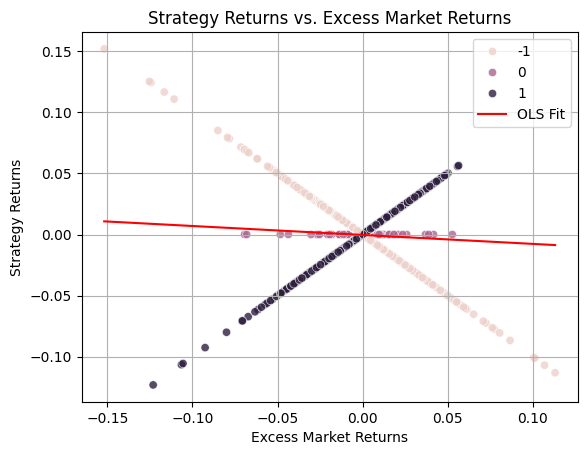

In [144]:
plot_df = s_df[['Excess Market Returns', 'Strategy Return', 'Signal']].copy()
sns.scatterplot(data=plot_df, x='Excess Market Returns', y='Strategy Return', hue='Signal', alpha=0.8)
plt.title('Strategy Returns vs. Excess Market Returns')
plt.xlabel('Excess Market Returns')
plt.ylabel('Strategy Returns')
plt.grid()

x_sorted = np.sort(plot_df['Excess Market Returns'].to_numpy())
y_fit = model.params['const'] + model.params['Excess Market Returns'] * x_sorted
plt.plot(x_sorted, y_fit, color='red', label='OLS Fit')
plt.legend()
plt.show()